In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully!')

All libraries imported successfully!


In [15]:
df = pd.read_csv(r'C:\Users\adapa\OneDrive\Documents\Liver Disease\Liver Patient Dataset (LPD)_train.csv', encoding='latin1')

df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)

df.rename(columns={
    'Age of the patient'                  : 'Age',
    'Gender of the patient'               : 'Gender',
    'Total Bilirubin'                     : 'Total_Bilirubin',
    'Direct Bilirubin'                    : 'Direct_Bilirubin',
    'Alkphos Alkaline Phosphotase'        : 'Alkaline_Phosphotase',
    'Sgpt Alamine Aminotransferase'       : 'ALT',
    'Sgot Aspartate Aminotransferase'     : 'AST',
    'Total Protiens'                      : 'Total_Proteins',
    'ALB Albumin'                         : 'Albumin',
    'A/G Ratio Albumin and Globulin Ratio': 'AG_Ratio',
    'Result'                              : 'Target'
}, inplace=True)

df['Target'] = df['Target'].map({1: 1, 2: 0})

print(f'Dataset Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Liver Disease  : {df["Target"].sum():,} patients')
print(f'No Disease     : {(df["Target"]==0).sum():,} patients')
df.head()

Dataset Shape  : 30,691 rows x 11 columns
Liver Disease  : 21,917 patients
No Disease     : 8,774 patients


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,ALT,AST,Total_Proteins,Albumin,AG_Ratio,Target
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [16]:
df['Gender'] = df['Gender'].astype(str).str.strip()
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

num_cols = df.select_dtypes(include=np.number).columns.tolist()
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Missing values after imputation : {df.isnull().sum().sum()}')
print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing samples  : {X_test.shape[0]:,}')

Missing values after imputation : 0
Training samples : 24,552
Testing samples  : 6,139


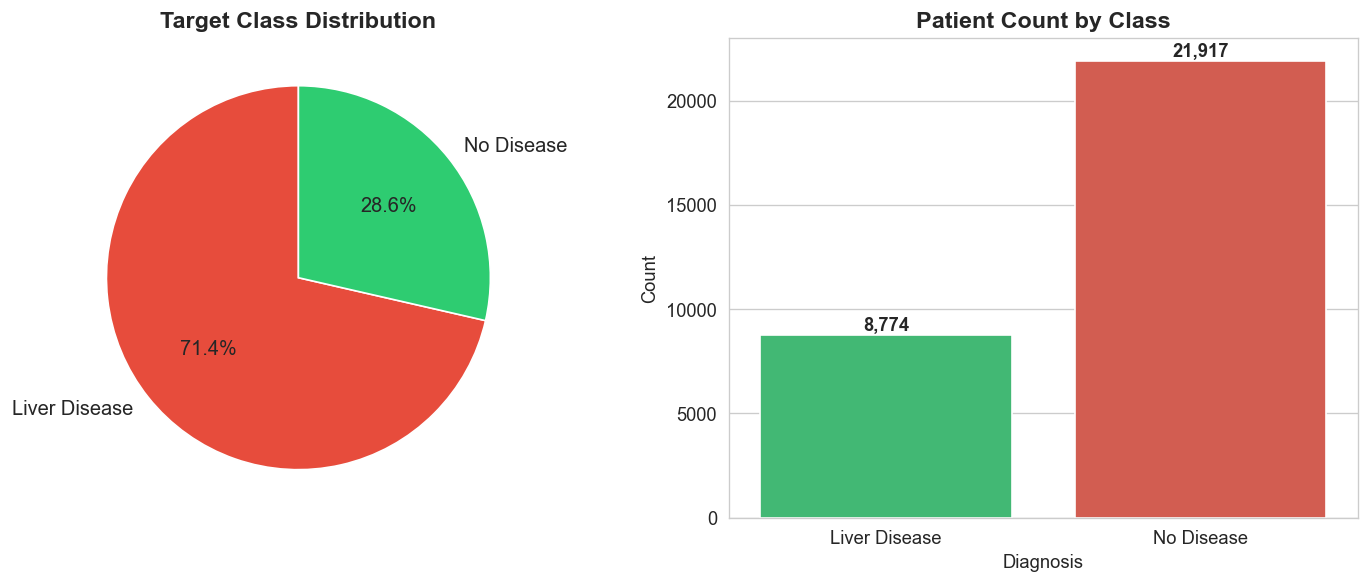

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = [df['Target'].sum(), (df['Target']==0).sum()]
labels = ['Liver Disease', 'No Disease']
colors = ['#E74C3C', '#2ECC71']

axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')

sns.countplot(x='Target', data=df, hue='Target',
              palette={1:'#E74C3C', 0:'#2ECC71'},
              legend=False, ax=axes[1])
axes[1].set_xticklabels(['Liver Disease', 'No Disease'])
axes[1].set_title('Patient Count by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

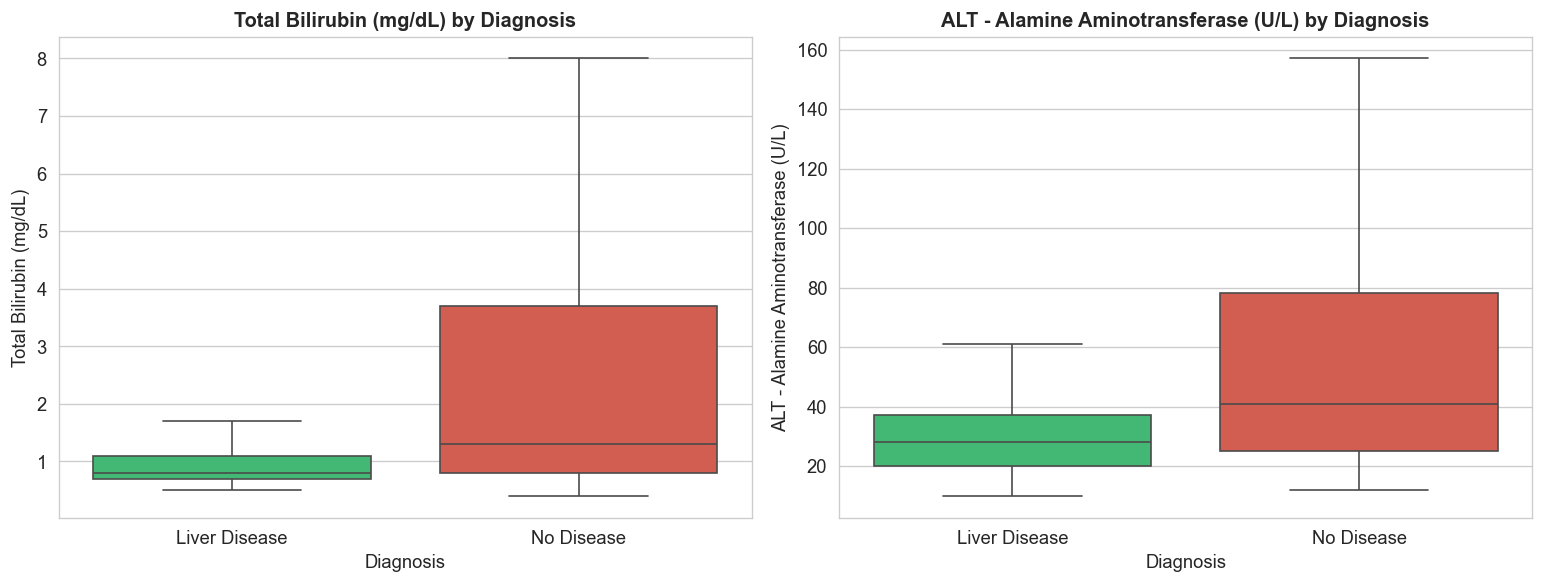

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes,
    ['Total_Bilirubin', 'ALT'],
    ['Total Bilirubin (mg/dL)', 'ALT - Alamine Aminotransferase (U/L)']):
    sns.boxplot(x='Target', y=col, data=df, hue='Target',
                palette={1:'#E74C3C', 0:'#2ECC71'},
                legend=False, ax=ax, showfliers=False)
    ax.set_xticklabels(['Liver Disease', 'No Disease'])
    ax.set_title(f'{title} by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('plot2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

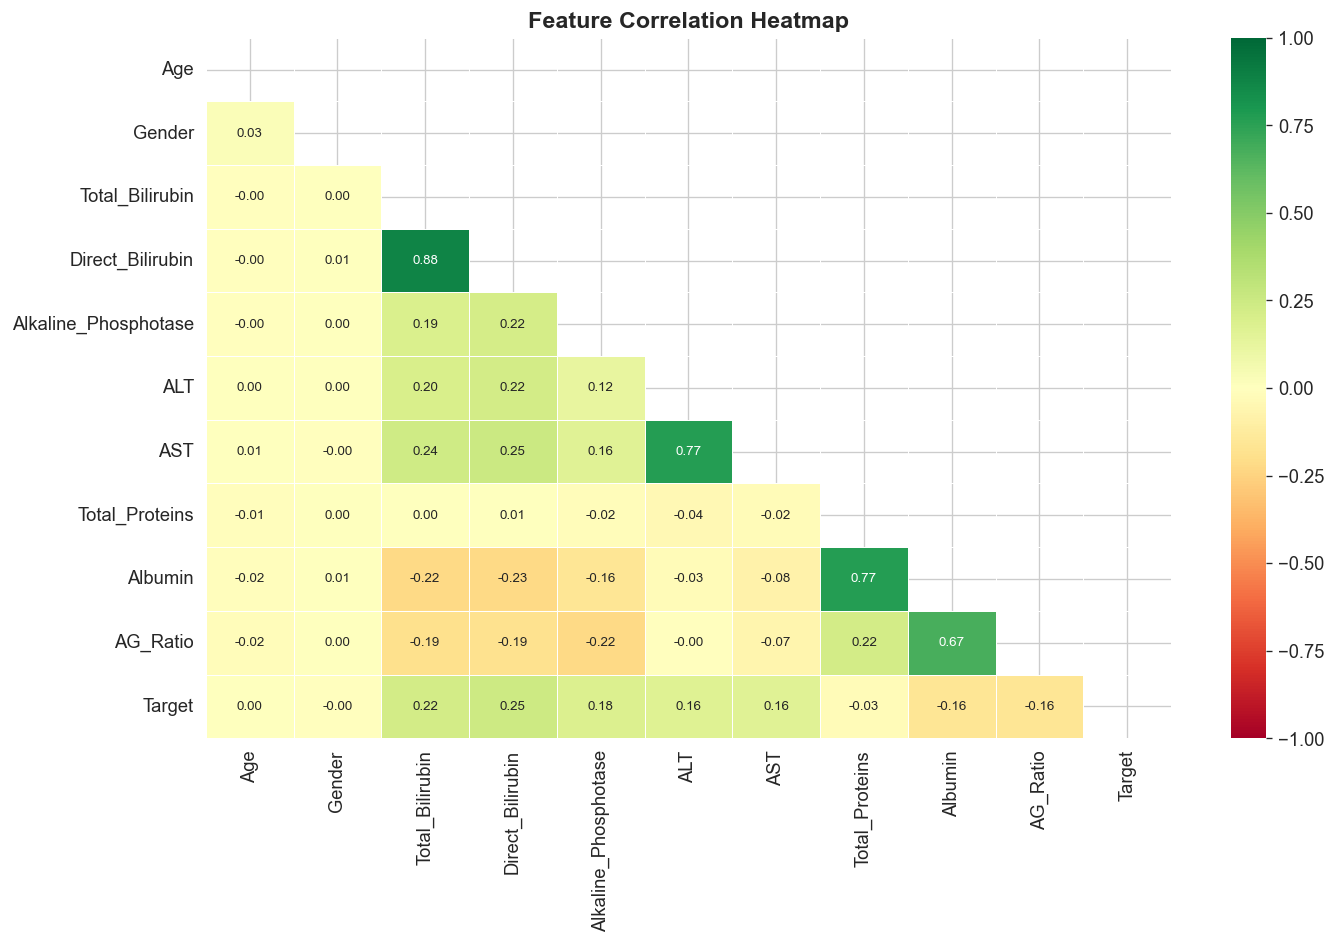

In [19]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
}

results = []
print('=' * 65)
print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10} {"CV Score":>10}')
print('=' * 65)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    roc    = roc_auc_score(y_test, y_prob)
    cv     = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy').mean()
    results.append({'Model': name, 'Accuracy': acc, 'ROC_AUC': roc, 'CV_Score': cv})
    print(f'{name:<25} {acc*100:>9.2f}% {roc:>10.4f} {cv*100:>9.2f}%')

print('=' * 65)
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(f'\nBest Model: {results_df.iloc[0]["Model"]} ({results_df.iloc[0]["Accuracy"]*100:.2f}% accuracy)')

Model                       Accuracy    ROC-AUC   CV Score
Logistic Regression           72.34%     0.7631     72.29%
Gradient Boosting             97.21%     0.9956     95.91%
Extra Trees                   99.76%     1.0000     99.76%
Random Forest                 99.84%     1.0000     99.78%

Best Model: Random Forest (99.84% accuracy)


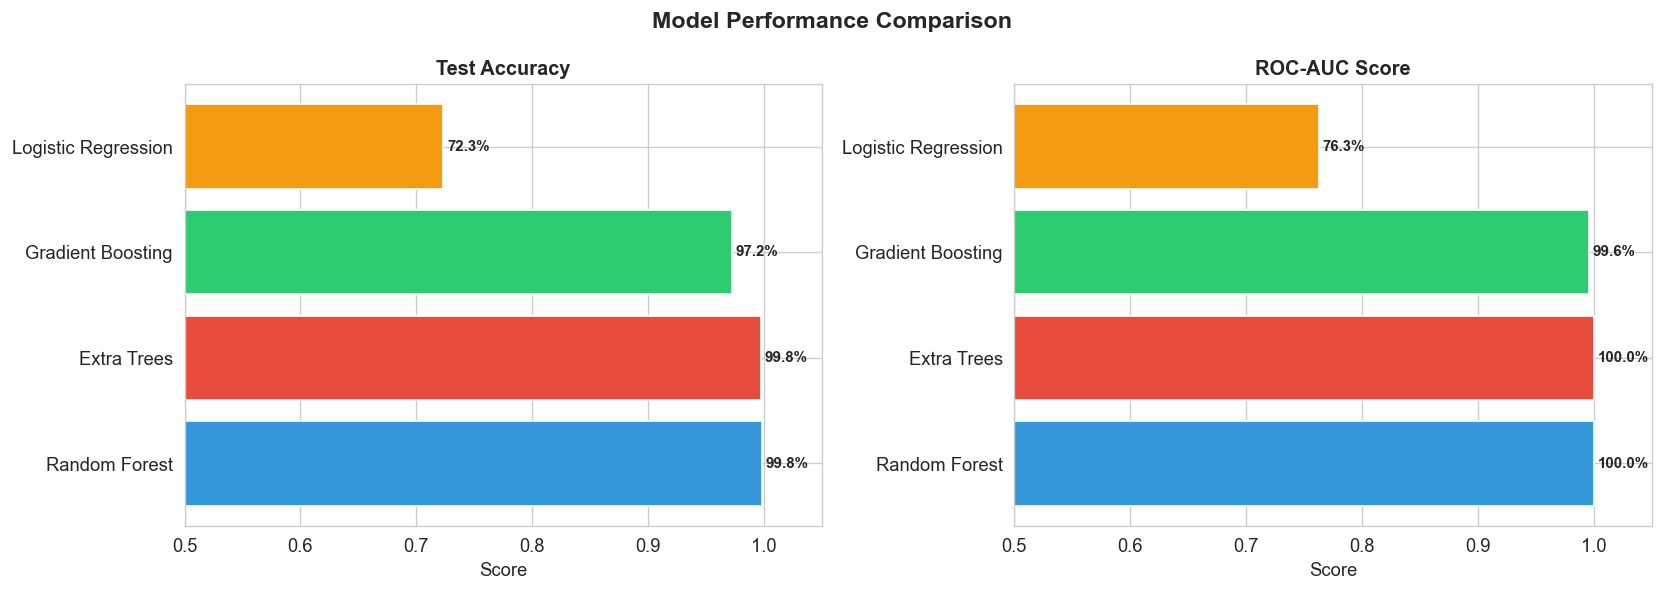

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

for ax, metric, title in zip(axes,
    ['Accuracy', 'ROC_AUC'],
    ['Test Accuracy', 'ROC-AUC Score']):
    bars = ax.barh(results_df['Model'], results_df[metric],
                   color=colors, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0.5, 1.05)
    ax.set_xlabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Random Forest Accuracy : 99.84%

Classification Report:
               precision    recall  f1-score   support

   No Disease       1.00      1.00      1.00      1755
Liver Disease       1.00      1.00      1.00      4384

     accuracy                           1.00      6139
    macro avg       1.00      1.00      1.00      6139
 weighted avg       1.00      1.00      1.00      6139



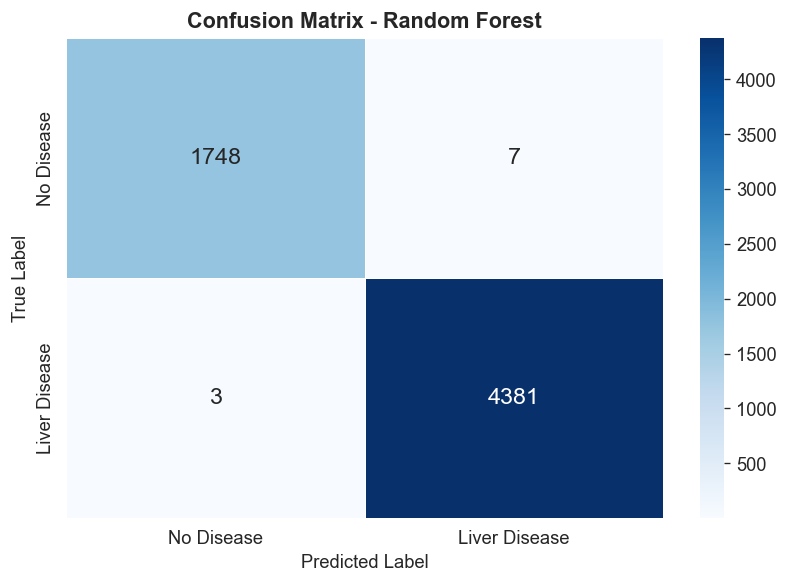

In [22]:
best_model  = models['Random Forest']
y_pred_best = best_model.predict(X_test_s)

acc = accuracy_score(y_test, y_pred_best)
print(f'Random Forest Accuracy : {acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Liver Disease']))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Liver Disease'],
            yticklabels=['No Disease', 'Liver Disease'],
            linewidths=0.5, annot_kws={'size': 14})
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plot5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

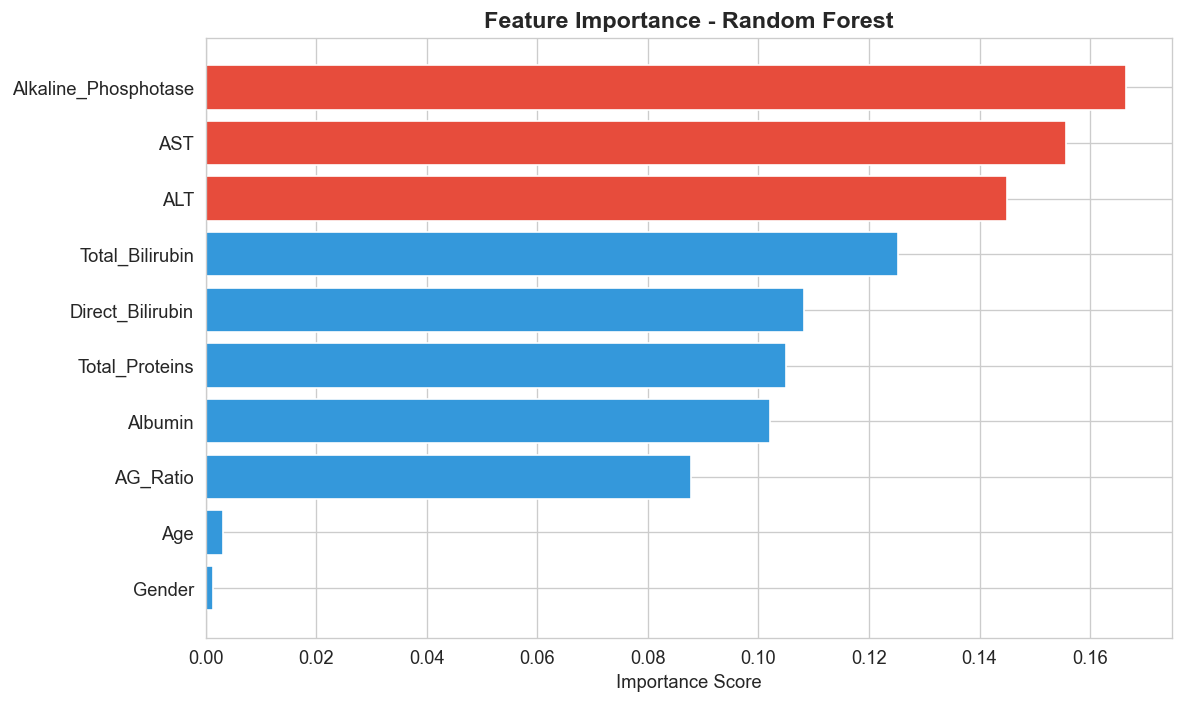

Top 5 Most Important Features:
             Feature  Importance
Alkaline_Phosphotase    0.166560
                 AST    0.155637
                 ALT    0.144973
     Total_Bilirubin    0.125281
    Direct_Bilirubin    0.108304


In [23]:
importances = best_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors_fi = ['#E74C3C' if i >= len(fi_df)-3 else '#3498DB'
             for i in range(len(fi_df))]
plt.barh(fi_df['Feature'], fi_df['Importance'],
         color=colors_fi, edgecolor='white')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Most Important Features:')
print(fi_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))